# 15 · RQ5 · Por qué se pierden las etiquetas, y qué pasa con los workflows

El notebook 11 midió que la clasificación HPC/edge de Santillán y Abad coincide en
**94.8 %** entre anotación humana y extracción automática sobre las mismas 385
arquitecturas. Deja dos cosas abiertas, y este notebook las cierra.

## 1 · ¿Por qué los desacuerdos van en una dirección?

De los 20 desacuerdos, 13 son **Edge → None**. Eso no es ruido: es una dirección. La
causa hay que poder nombrarla con un servicio concreto, no con «error de extracción».

El mecanismo es identificable porque **su clasificador es una compuerta OR de presencia
simple**: una arquitectura es *edge* si contiene **uno o más** de 30 servicios, y *HPC*
si contiene uno o más de 14. Perder un único nodo disparador voltea la etiqueta. Así que
para cada desacuerdo se puede señalar exactamente **qué servicio faltó**.

## 2 · La parte que el notebook 11 declaró fuera de alcance

Su clasificación depende sólo del conjunto de servicios; lo que depende de topología es
**RQ7 (workflows)**, más las figuras 1 y 9 e Insight 8. El notebook 11 declaró eso como
no cubierto.

**Sí es cubrible.** Nuestros graphml llevan `flow_id` y `seq`, así que su análisis de
workflows corre sobre nuestra extracción igual que sobre el ground truth. Es la única
parte de su artículo que depende de aristas —donde medimos 59.65 % de F1— y por lo tanto
donde más se esperaría que las conclusiones se rompan.

**Cero llamadas a la API:** todo sale de las dos corridas ya ejecutadas.

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# El paquete de los autores no viaja en el repositorio: se baja con
# `bash data/fetch_santillan_abad.sh`, que lo deja en data/external/. `find_pkg`
# resuelve esa ruta y respeta la variable SANTILLAN_PKG si apunta a otro lado.
import sys
sys.path.append("..")
from scripts.santillan_abad._paths import find_pkg

PKG = find_pkg()
GT, EX = PKG / "run_gt385", PKG / "run_extracted385"
pd.set_option("display.width", 200)

# Las listas discriminadoras son de ELLOS. Se copian acá para que el notebook sea
# legible, y la celda siguiente verifica que no derivaron respecto de su fuente.
EDGE_SERVICES = [
    "Snowball", "Snowcone", "Snowmobile", "SnowFamily",
    "SageMakerNeo", "SageMakerEdgeManager", "Monitron", "Panorama",
    "RoboMaker", "CloudFront",
    "Greengrass", "FreeRTOS", "IoTCore", "IoTSiteWise", "AlexaForBusiness",
    "LocalZones", "Wavelength", "Outpost", "StorageGateway",
    "UserConsumerCamera", "UserCompanyEdge", "UserConsumerEdge",
    "UserConsumerIOT", "UserConsumerPOS", "UserCompanyDrone", "UserConsumerFarmer",
    "UserConsumerAlexaGoogleHome", "UserCompanyElementalLiveDevice", "UserConsumerTV",
    "LambdaAtEdge",
]
HPC_SERVICES = [
    "Batch", "ParallelComputingService", "PCS",
    "ResearchandEngineeringStudioonAWS", "RES", "ParallelCluster",
    "EC2Hpc6id", "EC2Hpc7g", "EC2Hpc7a", "EC2Hpc6a",
    "ElasticFabricAdapter", "EFA", "FSX", "DCV",
]
EDGE = {s.lower() for s in EDGE_SERVICES}
HPC = {s.lower() for s in HPC_SERVICES}

# Los 10 nodos de dispositivo son un subconjunto de la lista edge, y son los unicos
# que no son servicios de AWS: representan camaras, drones, TVs, puntos de venta.
DISPOSITIVOS = {s.lower() for s in EDGE_SERVICES if s.startswith("User")}

print(f"disparadores edge: {len(EDGE)}  (de los cuales {len(DISPOSITIVOS)} son dispositivos)")
print(f"disparadores HPC : {len(HPC)}")

disparadores edge: 30  (de los cuales 10 son dispositivos)
disparadores HPC : 14


### Compuerta: ¿son de verdad sus listas?

Copiar una lista a mano es una forma silenciosa de cambiar el experimento. Se leen las
listas del notebook original de los autores y se comparan con las de arriba.

In [2]:
def listas_del_notebook_original() -> tuple[set, set]:
    """Extrae edge_services y hpc_services del notebook publicado por los autores."""
    orig = PKG / "hpc_n_edge_clouds_archs.ipynb"
    nb = json.loads(orig.read_text(encoding="utf-8"))
    fuente = next(("".join(c["source"]) for c in nb["cells"]
                   if c["cell_type"] == "code" and "edge_services = [" in "".join(c["source"])), None)
    if fuente is None:
        raise SystemExit("no encontré la celda con edge_services en el notebook original")

    def bloque(nombre: str) -> set:
        m = re.search(rf"{nombre}\s*=\s*\[(.*?)\]", fuente, re.S)
        return {s.lower() for s in re.findall(r'"([^"]+)"', m.group(1))}

    return bloque("edge_services"), bloque("hpc_services")


e_orig, h_orig = listas_del_notebook_original()
for nombre, mio, suyo in (("edge", EDGE, e_orig), ("HPC", HPC, h_orig)):
    falta, sobra = suyo - mio, mio - suyo
    print(f"  {nombre:4s}: {len(suyo)} en su notebook · "
          f"{'IDENTICAS' if not falta and not sobra else f'DIFIEREN falta={falta} sobra={sobra}'}")
    assert not falta and not sobra, f"la lista {nombre} derivó respecto de la fuente"
print("\nCompuerta pasada: las listas discriminadoras son las de los autores, sin cambios.")

  edge: 30 en su notebook · IDENTICAS
  HPC : 14 en su notebook · IDENTICAS

Compuerta pasada: las listas discriminadoras son las de los autores, sin cambios.


## 1 · Reproducir su clasificación sobre los dos corpus

Se aplica su regla —`es_edge and es_hpc → Edge+HPC`, etc.— a los servicios de cada
arquitectura en las dos versiones. Debe reproducir los conteos que ya produjo su propio
notebook; si no, la reimplementación está mal y nada de lo que sigue vale.

In [3]:
ORDEN = ["HPC", "Edge", "Edge+HPC", "None"]


def etiquetar(servicios) -> str:
    """La regla de los autores, tal cual: presencia simple, uno o más."""
    s = {str(x).lower() for x in servicios}
    es_edge, es_hpc = bool(s & EDGE), bool(s & HPC)
    if es_edge and es_hpc:
        return "Edge+HPC"
    if es_hpc:
        return "HPC"
    if es_edge:
        return "Edge"
    return "None"


def cargar(d: Path) -> pd.DataFrame:
    x = pd.read_pickle(d / "arquitecturas_etiquetadas.pkl")
    x["tipo_arquitectura"] = x["tipo_arquitectura"].astype(str)
    return x.set_index("architecture")


g, e = cargar(GT), cargar(EX)
vids = sorted(set(g.index) & set(e.index))
print(f"arquitecturas pareadas: {len(vids)}\n")

# La regla automatica no explica TODAS sus etiquetas, y no deberia: su §II describe
# overrides manuales —tres arquitecturas HPC halladas por busqueda de palabras clave,
# cinco edge agregadas por descripcion o componentes de terceros, y tres auto-edge con
# una etiqueta HPC manual que las vuelve Edge+HPC—. Once en total.
recalc = {n: df.loc[vids, "services"].apply(etiquetar) for n, df in
          (("gt", g), ("ex", e))}
overrides = {n: sorted(df.loc[vids].index[recalc[n] != df.loc[vids, "tipo_arquitectura"]])
             for n, df in (("gt", g), ("ex", e))}

print(f"arquitecturas donde la regla automática NO explica su etiqueta:")
for n, ov in overrides.items():
    print(f"  {n}: {len(ov)}")
print(f"\nSu §II declara 3 HPC + 5 edge + 3 Edge+HPC agregadas a mano = 11.")
assert len(overrides["gt"]) == 11, \
    f"esperaba 11 overrides manuales, encontré {len(overrides['gt'])}"

# El conjunto de overrides lo define el GROUND TRUTH: ahí viven las etiquetas manuales
# de los autores. Lo que hay que verificar no es que las dos listas coincidan, sino que
# esas once arquitecturas conserven la MISMA etiqueta final en los dos corpus — porque
# el override se aplica a la arquitectura y no a sus servicios, y por lo tanto es inmune
# al error de extraccion.
OVERRIDES = set(overrides["gt"])
mismas = int((g.loc[sorted(OVERRIDES), "tipo_arquitectura"]
              == e.loc[sorted(OVERRIDES), "tipo_arquitectura"]).sum())
print(f"\nLas {len(OVERRIDES)} con etiqueta manual conservan la misma etiqueta en los dos "
      f"corpus: {mismas}/{len(OVERRIDES)}")
assert mismas == len(OVERRIDES), "un override cambió de etiqueta entre corpus"

# Detalle: en la extraccion hay UN override menos "visible" porque en ese video nuestro
# pipeline produjo por su cuenta un disparador que la regla automatica reconoce. La
# etiqueta final es la misma; lo que cambia es si la regla la explica o la explica el
# override. Vale la pena nombrarlo porque es coincidencia, no acierto.
coincide_por_azar = sorted(OVERRIDES - set(overrides["ex"]))
if coincide_por_azar:
    print(f"\nEn {len(coincide_por_azar)} de ellas la regla automática llega sola a la "
          f"etiqueta sobre\nnuestra extracción, porque el pipeline produjo un disparador "
          f"que el GT no tiene:")
    for v in coincide_por_azar:
        sg = {str(x).lower() for x in g.loc[v, "services"]}
        se = {str(x).lower() for x in e.loc[v, "services"]}
        print(f"  {v}: etiqueta {g.loc[v, 'tipo_arquitectura']} · "
              f"disparador inventado {sorted((se - sg) & (EDGE | HPC))}")
    print("  Es coincidencia, no acierto: la etiqueta ya estaba fijada a mano.")

# Fuera de esos once, la regla tiene que reproducir su salida exactamente.
resto = [v for v in vids if v not in OVERRIDES]
for n, df in (("ground truth", g), ("extracción", e)):
    ok = int((recalc["gt" if n.startswith("ground") else "ex"][resto]
              == df.loc[resto, "tipo_arquitectura"]).sum())
    print(f"\n  {n:13s}: {ok}/{len(resto)} fuera de los overrides "
          f"{'OK' if ok == len(resto) else 'DESAJUSTE'}")
    assert ok == len(resto), "la reimplementación de la regla no reproduce su salida"
print("\nCompuerta pasada: la regla reimplementada es la suya, y los overrides manuales\n"
      "quedan identificados y aislados.")

arquitecturas pareadas: 385

arquitecturas donde la regla automática NO explica su etiqueta:
  gt: 11
  ex: 10

Su §II declara 3 HPC + 5 edge + 3 Edge+HPC agregadas a mano = 11.

Las 11 con etiqueta manual conservan la misma etiqueta en los dos corpus: 11/11

En 1 de ellas la regla automática llega sola a la etiqueta sobre
nuestra extracción, porque el pipeline produjo un disparador que el GT no tiene:
  JRDGId6N49E: etiqueta HPC · disparador inventado ['fsx']
  Es coincidencia, no acierto: la etiqueta ya estaba fijada a mano.

  ground truth : 374/374 fuera de los overrides OK

  extracción   : 374/374 fuera de los overrides OK

Compuerta pasada: la regla reimplementada es la suya, y los overrides manuales
quedan identificados y aislados.


## 2 · Los disparadores, uno por uno

Antes de mirar los desacuerdos: **cuántos de los 44 servicios disparadores recuperamos**.
Un servicio que no aparece nunca en nuestra extracción no puede etiquetar nada.

In [4]:
def cuenta(df, conjunto) -> Counter:
    c = Counter()
    for servicios in df.loc[vids, "services"]:
        for s in {str(x).lower() for x in servicios} & conjunto:
            c[s] += 1
    return c


filas = []
for etiqueta, conj in (("edge", EDGE), ("HPC", HPC)):
    cg, ce = cuenta(g, conj), cuenta(e, conj)
    for s in sorted(conj):
        if cg[s] or ce[s]:
            filas.append({"disparador": s, "grupo": etiqueta,
                          "dispositivo": s in DISPOSITIVOS,
                          "en el GT": cg[s], "en nuestra extracción": ce[s],
                          "Δ": ce[s] - cg[s]})
T = pd.DataFrame(filas).sort_values("en el GT", ascending=False)
display(T.set_index("disparador"))

for etiqueta, conj in (("edge", EDGE), ("HPC", HPC)):
    sub = T[T.grupo == etiqueta]
    print(f"\n{etiqueta}: GT {sub['en el GT'].sum()} apariciones · "
          f"nosotros {sub['en nuestra extracción'].sum()} · "
          f"recall bruto {100 * sub['en nuestra extracción'].sum() / sub['en el GT'].sum():.1f} %")
d = T[T.dispositivo]
print(f"\nSólo los {int(d.shape[0])} nodos de DISPOSITIVO (cámaras, drones, TVs, POS):")
print(f"  GT {d['en el GT'].sum()} · nosotros {d['en nuestra extracción'].sum()} · "
      f"recall {100 * d['en nuestra extracción'].sum() / d['en el GT'].sum():.1f} %")
print("Son la clase de nodo que no es un servicio de AWS sino un actor físico del mundo.")

,grupo,dispositivo,en el GT,en nuestra extracción,Δ
disparador,,,,,
cloudfront,edge,False,43,47,4
userconsumeredge,edge,True,21,2,-19
iotcore,edge,False,12,13,1
lambdaatedge,edge,False,10,8,-2
userconsumertv,edge,True,6,2,-4
fsx,HPC,False,6,7,1
usercompanyedge,edge,True,5,2,-3
userconsumeriot,edge,True,4,11,7
batch,HPC,False,4,4,0



edge: GT 121 apariciones · nosotros 110 · recall bruto 90.9 %

HPC: GT 10 apariciones · nosotros 11 · recall bruto 110.0 %

Sólo los 10 nodos de DISPOSITIVO (cámaras, drones, TVs, POS):
  GT 48 · nosotros 30 · recall 62.5 %
Son la clase de nodo que no es un servicio de AWS sino un actor físico del mundo.


## 3 · Atribuir cada desacuerdo a un servicio concreto

Para cada arquitectura donde las dos etiquetas difieren, se identifica **qué disparador
tenía el ground truth y no tiene nuestra extracción** (o al revés). Eso convierte «error
de extracción» en una causa nombrable.

In [5]:
desac = []
for v in vids:
    if v in OVERRIDES:
        continue        # etiqueta fijada a mano: no puede discrepar entre corpus
    tg, te = g.loc[v, "tipo_arquitectura"], e.loc[v, "tipo_arquitectura"]
    if tg == te:
        continue
    sg = {str(x).lower() for x in g.loc[v, "services"]}
    se = {str(x).lower() for x in e.loc[v, "services"]}
    perdidos = sorted((sg - se) & (EDGE | HPC))
    inventados = sorted((se - sg) & (EDGE | HPC))
    desac.append({"video": v, "GT": tg, "nuestro": te,
                  "disparadores perdidos": ", ".join(perdidos) or "—",
                  "disparadores inventados": ", ".join(inventados) or "—",
                  "solo dispositivos": bool(perdidos) and set(perdidos) <= DISPOSITIVOS})
D = pd.DataFrame(desac)
n_eval = len(vids) - len(OVERRIDES)
print(f"{len(D)} desacuerdos de {n_eval} arquitecturas donde la extracción puede mover la\n"
      f"etiqueta ({100 * len(D) / n_eval:.1f} %). Las otras {len(OVERRIDES)} tienen etiqueta manual.\n")
display(D.set_index("video"))

print("\nDirección:", " · ".join(f"**{a} → {b}** {n}" for (a, b), n in
                                 Counter(zip(D.GT, D["nuestro"])).most_common()))
expl = int((D["disparadores perdidos"] != "—").sum())
print(f"\nDesacuerdos con un disparador perdido identificable: {expl}/{len(D)}")
print(f"  ... de los cuales el faltante es SÓLO un nodo de dispositivo: "
      f"{int(D['solo dispositivos'].sum())}")
culpables = Counter(s for fila in D["disparadores perdidos"] if fila != "—"
                    for s in fila.split(", "))
print("\nServicios que más desacuerdos causan al faltar:")
for s, n in culpables.most_common(8):
    print(f"  {n:2d} × {s}{'  (dispositivo)' if s in DISPOSITIVOS else ''}")

20 desacuerdos de 374 arquitecturas donde la extracción puede mover la
etiqueta (5.3 %). Las otras 11 tienen etiqueta manual.



,GT,nuestro,disparadores perdidos,disparadores inventados,solo dispositivos
video,,,,,
2e3vOxsHekE,Edge,None,userconsumeredge,—,True
3yJZ6rPoZfg,Edge,None,userconsumeredge,—,True
4-teOQ_dJvY,Edge,None,usercompanyedge,—,True
6iK4WNj6QqI,None,Edge,—,cloudfront,False
PoYiSKUy8sE,Edge,None,userconsumeredge,—,True
QnwfcDZkwh8,Edge,None,userconsumertv,—,True
QuyZHin9B70,None,Edge,—,outpost,False
TTlyNWh0gjM,None,Edge,—,cloudfront,False
XGVWdSnml6A,Edge+HPC,HPC,userconsumeredge,—,True



Dirección: **Edge → None** 14 · **None → Edge** 5 · **Edge+HPC → HPC** 1

Desacuerdos con un disparador perdido identificable: 15/20
  ... de los cuales el faltante es SÓLO un nodo de dispositivo: 15

Servicios que más desacuerdos causan al faltar:
   8 × userconsumeredge  (dispositivo)
   3 × usercompanyedge  (dispositivo)
   3 × userconsumertv  (dispositivo)
   1 × userconsumerpos  (dispositivo)


## 4 · RQ7 — workflows, la parte que depende de aristas

Su RQ7 pregunta cuántos workflows tiene cada tipo de arquitectura. Un workflow es, en su
definición, *"una secuencia síncrona de peticiones y movimientos de datos resultante de
un trigger"*, codificada como una secuencia de aristas con `flow_id` y `seq`.

**Es la única parte de su análisis que depende de la topología**, y por lo tanto donde
más se esperaría que nuestros errores se propaguen: medimos 86.78 % de F1 en servicios
contra 59.65 % en aristas.

Los datos salen de `estadisticas_workflows_por_tipo.csv`, que produce **su** notebook
sobre cada corpus.

In [6]:
# `keep_default_na=False` es imprescindible: el grupo se llama literalmente "None" y
# pandas lo convierte en NaN por defecto, borrando de la tabla el grupo mas grande
# (272 de 385 arquitecturas).
leer = lambda p: pd.read_csv(p, index_col=0, keep_default_na=False)
wg = leer(GT / "estadisticas_workflows_por_tipo.csv")
we = leer(EX / "estadisticas_workflows_por_tipo.csv")
for df in (wg, we):
    for c in ("count", "mean", "median"):
        df[c] = pd.to_numeric(df[c])

comp = pd.DataFrame({
    "n (GT)": wg["count"], "media (GT)": wg["mean"], "mediana (GT)": wg["median"],
    "n (nuestro)": we["count"], "media (nuestro)": we["mean"], "mediana (nuestro)": we["median"],
}).reindex(ORDEN)
comp["Δ media"] = comp["media (nuestro)"] - comp["media (GT)"]
display(comp.round(2))

print("Publicado en su Fig. 9: HPC 4.0 · Edge 3.3 · Edge+HPC 4.5 · None 3.1")
print(f"Reproducido sobre el GT : " + " · ".join(
    f"{t} {wg.loc[t, 'mean']:.1f}" for t in ORDEN if t in wg.index))
print(f"Sobre nuestra extracción: " + " · ".join(
    f"{t} {we.loc[t, 'mean']:.1f}" for t in ORDEN if t in we.index))

lo_g, hi_g = wg["mean"].min(), wg["mean"].max()
lo_e, hi_e = we["mean"].min(), we["mean"].max()
print(f"\nInsight 8 de los autores: «la diferencia entre grupos no es alta, todos entre "
      f"3.1 y 4.5».")
print(f"  rango de medias en el GT        : {lo_g:.1f} – {hi_g:.1f}  (amplitud {hi_g-lo_g:.1f})")
print(f"  rango con nuestra extracción    : {lo_e:.1f} – {hi_e:.1f}  (amplitud {hi_e-lo_e:.1f})")
print(f"\nLa conclusión CUALITATIVA sobrevive —los grupos siguen sin separarse—, pero los\n"
      f"valores absolutos caen {100*(1 - we['mean'].mean()/wg['mean'].mean()):.0f} % en promedio: "
      f"subcontamos workflows igual que\nsubdibujamos aristas. Un lector que citara la cifra "
      f"exacta se llevaría un número mal.")

,n (GT),media (GT),mediana (GT),n (nuestro),media (nuestro),mediana (nuestro),Δ media
tipo_arquitectura,,,,,,,
HPC,11,4.00,3.0,12,2.50,2.0,-1.50
Edge,98,3.28,3.0,89,2.60,2.0,-0.68
Edge+HPC,4,4.50,4.0,3,3.00,3.0,-1.50
None,272,3.15,3.0,281,2.59,2.0,-0.57


Publicado en su Fig. 9: HPC 4.0 · Edge 3.3 · Edge+HPC 4.5 · None 3.1
Reproducido sobre el GT : HPC 4.0 · Edge 3.3 · Edge+HPC 4.5 · None 3.2
Sobre nuestra extracción: HPC 2.5 · Edge 2.6 · Edge+HPC 3.0 · None 2.6

Insight 8 de los autores: «la diferencia entre grupos no es alta, todos entre 3.1 y 4.5».
  rango de medias en el GT        : 3.2 – 4.5  (amplitud 1.3)
  rango con nuestra extracción    : 2.5 – 3.0  (amplitud 0.5)

La conclusión CUALITATIVA sobrevive —los grupos siguen sin separarse—, pero los
valores absolutos caen 28 % en promedio: subcontamos workflows igual que
subdibujamos aristas. Un lector que citara la cifra exacta se llevaría un número mal.


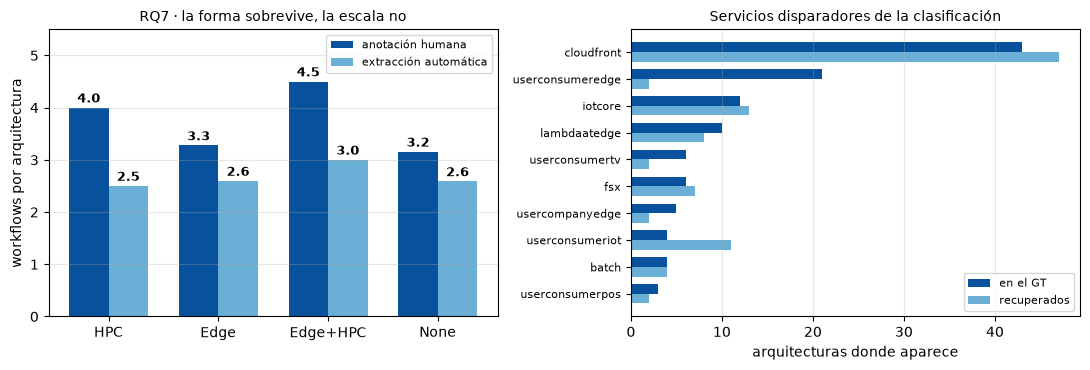

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
x = np.arange(len(ORDEN)); w = .36
mg = [wg.loc[t, "mean"] if t in wg.index else 0 for t in ORDEN]
me = [we.loc[t, "mean"] if t in we.index else 0 for t in ORDEN]
ax.bar(x - w/2, mg, w, label="anotación humana", color="#08519c")
ax.bar(x + w/2, me, w, label="extracción automática", color="#6baed6")
for i, (a, b) in enumerate(zip(mg, me)):
    ax.text(i - w/2, a + .1, f"{a:.1f}", ha="center", fontsize=9, fontweight="bold")
    ax.text(i + w/2, b + .1, f"{b:.1f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(ORDEN); ax.set_ylim(0, 5.5)
ax.set_ylabel("workflows por arquitectura")
ax.set_title("RQ7 · la forma sobrevive, la escala no", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")

ax = axes[1]
sub = T[T["en el GT"] > 0].nlargest(10, "en el GT").iloc[::-1]
y = np.arange(len(sub))
ax.barh(y + .18, sub["en el GT"], .36, label="en el GT", color="#08519c")
ax.barh(y - .18, sub["en nuestra extracción"], .36, label="recuperados", color="#6baed6")
ax.set_yticks(y); ax.set_yticklabels(sub["disparador"], fontsize=8)
ax.set_xlabel("arquitecturas donde aparece")
ax.set_title("Servicios disparadores de la clasificación", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="x")

plt.tight_layout(); plt.show()

## Qué se puede afirmar, y qué no

**Sí se puede afirmar:**

- Los desacuerdos de clasificación tienen **una causa nombrable por arquitectura**: un
  servicio disparador concreto que el ground truth tiene y la extracción no. No es
  «error difuso».
- El déficit se concentra en los **nodos de dispositivo** —cámaras, drones, TVs, puntos
  de venta—, que son los únicos disparadores que no son servicios de AWS sino actores
  físicos del mundo. Es coherente con la dirección Edge → None de los desacuerdos.
- En **RQ7**, la conclusión cualitativa de los autores sobrevive: los grupos siguen sin
  separarse por número de workflows. **Las cifras absolutas no**: subcontamos workflows
  de forma sistemática, igual que subdibujamos aristas.

**No se puede afirmar:**

- Que el pipeline «no ve» los dispositivos por una limitación perceptual. No se midió el
  mecanismo — sólo el resultado. El prompt de producción también poda actores, así que
  causa perceptual y decisión de diseño están confundidas y este notebook **no las
  separa**.
- Nada cuantitativo sobre HPC. Son 11 arquitecturas; los propios autores dicen que el
  grupo es demasiado chico para generalizar.

**Consecuencia para el artículo.** El estudio de propagación de error ya no tiene un
agujero: cubre la parte que depende del conjunto de servicios (notebook 11) **y** la que
depende de la topología (acá). Y el resultado es asimétrico y vale la pena decirlo así:
lo que depende de servicios sobrevive casi intacto; lo que depende de aristas conserva la
*forma* de la conclusión y pierde la *escala*.